In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pandas as pd
import numpy as np
train = pd.read_csv('../data/train.csv')
stores = pd.read_csv('../data/stores.csv')
features = pd.read_csv('../data/features.csv')

print("Raw shapes:")
print(f"train:     {train.shape}")
print(f"stores:    {stores.shape}")
print(f"features:  {features.shape}")

# Convert dates
train['Date'] = pd.to_datetime(train['Date'])
features['Date'] = pd.to_datetime(features['Date'])

print("\n Step 1: Merge train + stores (Store only)")
df1 = train.merge(stores, on='Store', how='left')
print(f"Step 1: {df1.shape}")

print("\n Step 2: Merge with features (Store+Date ONLY)")
df = df1.merge(features, on=['Store', 'Date'], how='left')
print(f" FINAL: {df.shape}")

print("\n New columns added:")
new_cols = [col for col in df.columns if col not in train.columns]
print("•", new_cols[:10])

print(f"\n SUCCESS! Full dataset: {df.shape[0]:,} rows")
print(f"External features: Temperature, Fuel_Price, CPI, MarkDown1-5")

Raw shapes:
train:     (421570, 5)
stores:    (45, 3)
features:  (8190, 12)

 Step 1: Merge train + stores (Store only)
Step 1: (421570, 7)

 Step 2: Merge with features (Store+Date ONLY)
 FINAL: (421570, 17)

 New columns added:
• ['IsHoliday_x', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

 SUCCESS! Full dataset: 421,570 rows
External features: Temperature, Fuel_Price, CPI, MarkDown1-5


## **Dataset Exploration & Pre-Processing**

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday_x   421570 non-null  bool          
 5   Type          421570 non-null  str           
 6   Size          421570 non-null  int64         
 7   Temperature   421570 non-null  float64       
 8   Fuel_Price    421570 non-null  float64       
 9   MarkDown1     150681 non-null  float64       
 10  MarkDown2     111248 non-null  float64       
 11  MarkDown3     137091 non-null  float64       
 12  MarkDown4     134967 non-null  float64       
 13  MarkDown5     151432 non-null  float64       
 14  CPI           421570 non-null  float64       
 15  Unemployment  421570 non-nul

## **Dataset Description**
## Problem Formulation
- Retail businesses must predict future demand to avoid **overstocking** (high holding cost) and **stock-outs** (lost sales).
- Sales demand varies by **time, store, department, promotions, holidays, and economic conditions**.
- This project formulates a **supervised weekly demand forecasting problem**.

**Objective**
- Predict **Weekly_Sales** for each **Store × Department × Week** using historical and external features.

---

## Dataset Overview
- **Rows:** 421,570 (one row = one store–department–week)
- **Target variable:** `Weekly_Sales`
- **Problem type:** Multivariate time-series forecasting with exogenous variables

---

## Column Description & Processing

### Identifiers
- **Store (int):** Store ID → *Keep, encode*
- **Dept (int):** Department ID → *Keep, encode*

### Time & Events
- **Date (datetime):** Weekly time index → *Keep, extract features (year, month, week)*
- **IsHoliday_x (bool):** Holiday indicator → *Keep*
- **IsHoliday_y (bool):** Duplicate holiday column → **Drop**

### Target
- **Weekly_Sales (float):** Weekly revenue → *Target variable (keep)*

### Store Characteristics
- **Type (A/B/C):** Store category → *Encode (one-hot)*
- **Size (int):** Store size → *Scale*

### Economic & Environmental Factors
- **Temperature (float):** Weather effect → *Scale*
- **Fuel_Price (float):** Transportation cost proxy → *Scale*
- **CPI (float):** Inflation indicator → *Scale*
- **Unemployment (float):** Economic health → *Scale*

### Promotions
- **MarkDown1–5 (float):** Promotional discounts  
  - NaN = no promotion  
  - *Impute with 0, scale*

---

## Final Note
- This dataset supports **store–department level weekly forecasting** by combining sales history with **calendar effects, promotions, store attributes, and macroeconomic signals**, enabling realistic retail demand prediction.


In [6]:
import os 
path = '/media/ibadat/NewVolume/DATA SCIENCE/ML/DATASCIENCE PROJECTS/Demand Sales Walmart Forecasting/Visuals'
os.makedirs(path,exist_ok = True)


In [7]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [8]:
df['Weekly_Sales'].describe().T

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

In [9]:
len(df['Weekly_Sales'])

421570

In [10]:
negative_sales = (df['Weekly_Sales']< 0) #negative ssales occur due to product returns
print(f"\nNegative sales records: {len(negative_sales):,} ({len(negative_sales)/len(df)*100:.2f}%)")




Negative sales records: 421,570 (100.00%)


In [11]:
#Null values dealing
missing_val = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_val/len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing_Count': missing_val,
    'Percentage': missing_pct
})

print(missing_df[missing_df['Missing_Count'] > 0])

           Missing_Count  Percentage
MarkDown2         310322       73.61
MarkDown4         286603       67.98
MarkDown3         284479       67.48
MarkDown1         270889       64.26
MarkDown5         270138       64.08


In [12]:
# checking other cols
print("\n4. STORE AND DEPARTMENT INFO")
print("-" * 80)
print(f"Number of stores: {df['Store'].nunique()}")
print(f"Number of departments: {df['Dept'].nunique()}")
print(f"Store types: {df['Type'].unique()}")
print(f"\nStore IDs: {sorted(df['Store'].unique())}")


4. STORE AND DEPARTMENT INFO
--------------------------------------------------------------------------------
Number of stores: 45
Number of departments: 81
Store types: <StringArray>
['A', 'B', 'C']
Length: 3, dtype: str

Store IDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45)]


In [13]:
print(df['Type'].value_counts()) #A for highest,B for mid,C for lowest 

Type
A    215478
B    163495
C     42597
Name: count, dtype: int64


In [14]:
#dealing with Date
print("\n DATE RANGE")
print("-" * 80)
print(f"Start date: {df['Date'].min()}")
print(f"End date: {df['Date'].max()}")
print(f"Weeks : {df['Date'].unique()}")
print(f"\nDuration: {(df['Date'].max() - df['Date'].min()).days / 7:.0f} weeks ({(df['Date'].max() - df['Date'].min()).days / 365:.1f} years)")




 DATE RANGE
--------------------------------------------------------------------------------
Start date: 2010-02-05 00:00:00
End date: 2012-10-26 00:00:00
Weeks : <DatetimeArray>
['2010-02-05 00:00:00', '2010-02-12 00:00:00', '2010-02-19 00:00:00',
 '2010-02-26 00:00:00', '2010-03-05 00:00:00', '2010-03-12 00:00:00',
 '2010-03-19 00:00:00', '2010-03-26 00:00:00', '2010-04-02 00:00:00',
 '2010-04-09 00:00:00',
 ...
 '2012-08-24 00:00:00', '2012-08-31 00:00:00', '2012-09-07 00:00:00',
 '2012-09-14 00:00:00', '2012-09-21 00:00:00', '2012-09-28 00:00:00',
 '2012-10-05 00:00:00', '2012-10-12 00:00:00', '2012-10-19 00:00:00',
 '2012-10-26 00:00:00']
Length: 143, dtype: datetime64[us]

Duration: 142 weeks (2.7 years)


**Interpretation:**
The dataset provides a clean, continuous weekly time series over 142 weeks (2010–2012), offering sufficient temporal coverage to model short-term dynamics and annual seasonality, while remaining limited in capturing long-term structural changes.

In [15]:
#checking holidays

print("\n. HOLIDAY ANALYSIS")
print("-" * 80)
holiday_weeks_x = df['IsHoliday_x'].sum()
holiday_weeks_y = df['IsHoliday_y'].sum()
print(f"Holiday weeks (IsHoliday_x): {holiday_weeks_x:,}")
print(f"Holiday weeks (IsHoliday_y): {holiday_weeks_y:,}")

# Average sales on holidays vs non-holidays
print(f"\nAverage sales on holidays: ${df[df['IsHoliday_x'] == True]['Weekly_Sales'].mean():,.2f}")
print(f"Average sales on non-holidays: ${df[df['IsHoliday_x'] == False]['Weekly_Sales'].mean():,.2f}")


. HOLIDAY ANALYSIS
--------------------------------------------------------------------------------
Holiday weeks (IsHoliday_x): 29,661
Holiday weeks (IsHoliday_y): 29,661

Average sales on holidays: $17,035.82
Average sales on non-holidays: $15,901.45


**Interpretations:**

- Holiday weeks exhibit approximately a 7% uplift in average weekly sales compared to non-holiday periods, confirming holidays as a significant demand driver that must be explicitly modeled to avoid systematic underforecasting.
- Higher sales during holiday weeks arise from a convergence of promotion intensity, demand concentration, increased basket size, and behavioral spending biases, making holidays structurally distinct from regular weeks rather than simple seasonal variations.

In [16]:
df = df.drop(columns = 'IsHoliday_y') #essential drop because as the x and y both are same so we have to keep one instead to two


In [17]:
df = df.rename(columns={'IsHoliday_x': 'IsHoliday'})
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


In [18]:
print("\n ECONOMIC INDICATORS SUMMARY")
print("-" * 80)
economic_features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
for feature in economic_features:
    if feature in df.columns:
        print(f"\n{feature}:")
        print(f"  Range: {df[feature].min():.2f} to {df[feature].max():.2f}")
        print(f"  Mean: {df[feature].mean():.2f}")
        print(f"  Missing: {df[feature].isnull().sum()}")


 ECONOMIC INDICATORS SUMMARY
--------------------------------------------------------------------------------

Temperature:
  Range: -2.06 to 100.14
  Mean: 60.09
  Missing: 0

Fuel_Price:
  Range: 2.47 to 4.47
  Mean: 3.36
  Missing: 0

CPI:
  Range: 126.06 to 227.23
  Mean: 171.20
  Missing: 0

Unemployment:
  Range: 3.88 to 14.31
  Mean: 7.96
  Missing: 0


**Interpretation:**

The economic indicators exhibit complete coverage, realistic variability, and no missingness, making them reliable exogenous variables that primarily influence baseline demand levels rather than short-term volatility, thereby improving long-horizon forecast stability.

In [19]:
#MARKDOWN are event-driven feature mostly shows the behaviour of promotions
print("\n. MARKDOWN ANALYSIS")
print("-" * 80)
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
for col in markdown_cols:
    if col in df.columns:
        non_null = df[col].notna().sum()
        pct_available = (non_null / len(df)) * 100
        print(f"{col}: {non_null:,} records ({pct_available:.1f}%) | Avg when available: ${df[col].mean():,.2f}")


. MARKDOWN ANALYSIS
--------------------------------------------------------------------------------
MarkDown1: 150,681 records (35.7%) | Avg when available: $7,246.42
MarkDown2: 111,248 records (26.4%) | Avg when available: $3,334.63
MarkDown3: 137,091 records (32.5%) | Avg when available: $1,439.42
MarkDown4: 134,967 records (32.0%) | Avg when available: $3,383.17
MarkDown5: 151,432 records (35.9%) | Avg when available: $4,628.98


**Interpretation:**

The markdown variables represent sparse but high-magnitude promotional interventions that act as intentional demand shocks, making them critical for accurately modeling sales volatility rather than baseline demand.

In [20]:
#Dealing with Null values
df[markdown_cols] = df[markdown_cols].fillna(0) #no promotion applied
df["Has_Markdown"] = (df[markdown_cols].sum(axis = 1) >0).astype(int) #if promotions applied
df["Total Markdown"] = df[markdown_cols].sum(axis=1) #keep total track of promotions weekly wise

In [21]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Has_Markdown,Total Markdown
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,0,0.0
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,0,0.0
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,0,0.0
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,0,0.0
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,0,0.0


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


## **Weekly Sales Over Time**

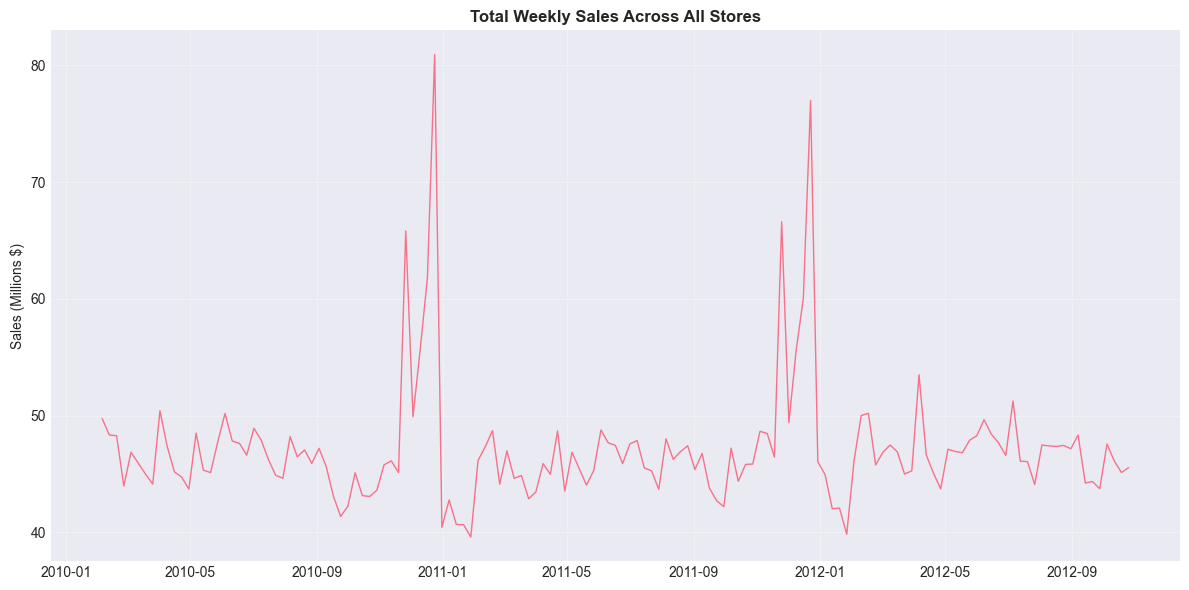

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

weekly_total = df.groupby('Date')['Weekly_Sales'].sum()
ax.plot(weekly_total.index, weekly_total.values / 1e6, linewidth=1)

ax.set_title('Total Weekly Sales Across All Stores', fontweight='bold')
ax.set_ylabel('Sales (Millions $)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(path, '01_weekly_sales_over_time.png'), dpi=300)
plt.show()


**Interpretation:**

- Sales are not random

- Clear repeating spikes every year

- Massive peaks around end of year

- Baseline weekly sales hover around $45–50M

- Two extreme spikes (~$80M+) indicate holiday seasons

## **Weekly Sales Distribution**

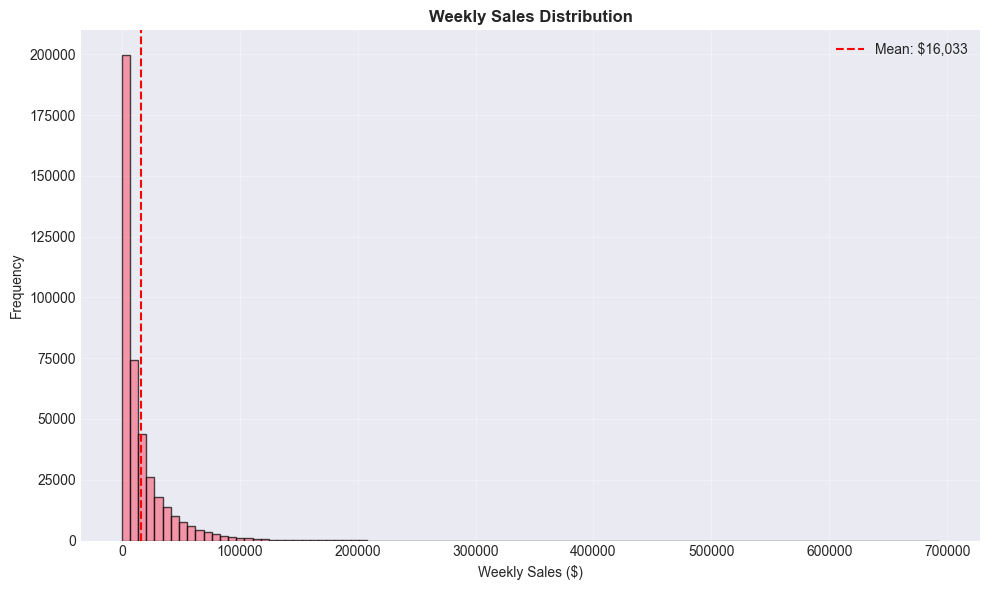

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

sales_filtered = df[df['Weekly_Sales'] > 0]['Weekly_Sales']
ax.hist(sales_filtered, bins=100, edgecolor='black', alpha=0.7)
ax.axvline(sales_filtered.mean(), color='red', linestyle='--',
           label=f"Mean: ${sales_filtered.mean():,.0f}")

ax.set_title('Weekly Sales Distribution', fontweight='bold')
ax.set_xlabel('Weekly Sales ($)')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(path, '02_weekly_sales_distribution.png'), dpi=300)
plt.show()


**Interpretation:**

- Distribution is heavily right-skewed

- Majority of weeks:

- Low-to-moderate sales

- Few weeks:

- Extremely high sales (long tail)

- Mean ≠ typical value (mean is pulled by extremes)

**Reason:**

- Most departments sell modestly

- A few departments/weeks sell exceptionally high

- This is normal retail behavior, not noise

## **Average Weekly Sales by Store Type**

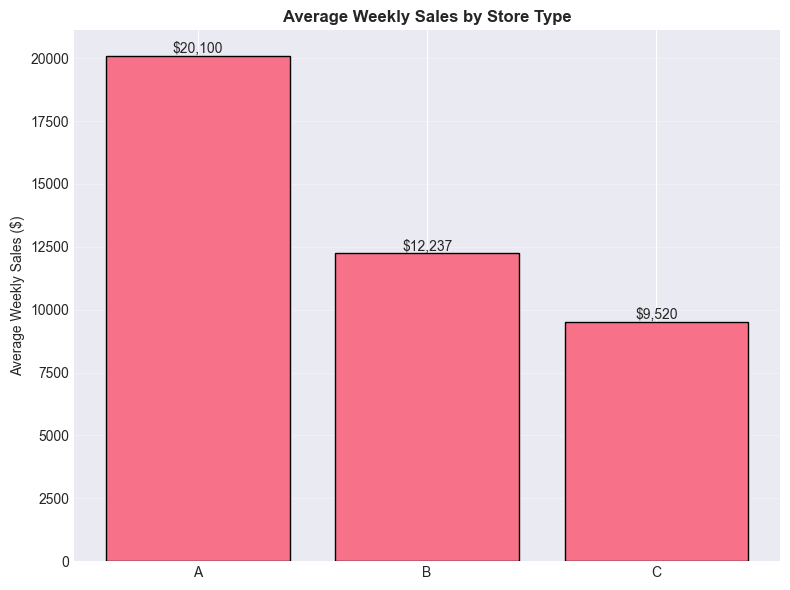

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))

store_type_sales = df.groupby('Type')['Weekly_Sales'].mean().sort_values(ascending=False)
ax.bar(store_type_sales.index, store_type_sales.values, edgecolor='black')

ax.set_title('Average Weekly Sales by Store Type', fontweight='bold')
ax.set_ylabel('Average Weekly Sales ($)')
ax.grid(True, axis='y', alpha=0.3)

for i, v in enumerate(store_type_sales.values):
    ax.text(i, v, f'${v:,.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(os.path.join(path, '03_sales_by_store_type.png'), dpi=300)
plt.show()


**Interpretations:**

- Type A > B > C consistently

**Clear hierarchy:**

- Type A ≈ $20k

- Type B ≈ $12k

- Type C ≈ $9.5k

**Reason:**

- Bigger stores → higher demand

- Store type is not cosmetic, it’s predictive

## **Holiday vs Non-Holiday Sales**


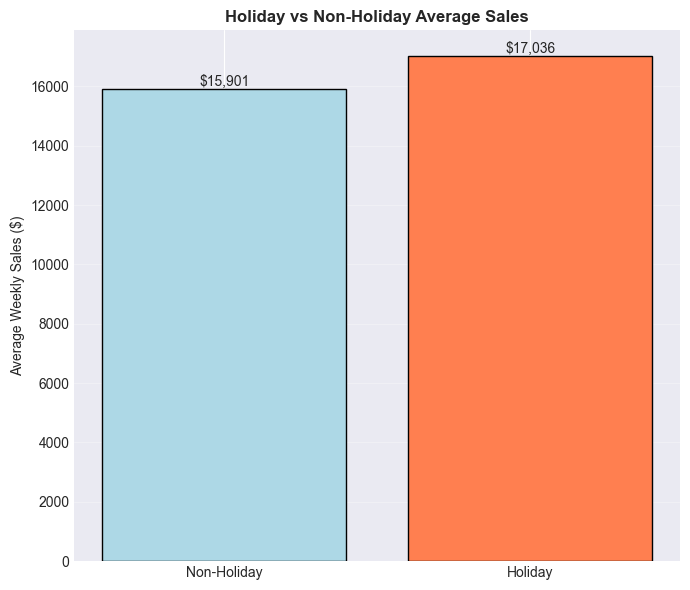

In [26]:
fig, ax = plt.subplots(figsize=(7, 6))

holiday_comparison = df.groupby('IsHoliday')['Weekly_Sales'].mean()
ax.bar(['Non-Holiday', 'Holiday'], holiday_comparison.values,
       color=['lightblue', 'coral'], edgecolor='black')

ax.set_title('Holiday vs Non-Holiday Average Sales', fontweight='bold')
ax.set_ylabel('Average Weekly Sales ($)')
ax.grid(True, axis='y', alpha=0.3)

for i, v in enumerate(holiday_comparison.values):
    ax.text(i, v, f'${v:,.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(os.path.join(path, '04_holiday_vs_nonholiday.png'), dpi=300)
plt.show()


**Interpretation:**

- Holiday weeks sell more than non-holiday
- 
- Increase ≈ 7% uplift

- Difference is consistent and meaningful

**Reason:**

Holidays cause:

- Bulk buying

- Promotions

- Higher basket sizes

## **Top 10 Stores by Total Sales**

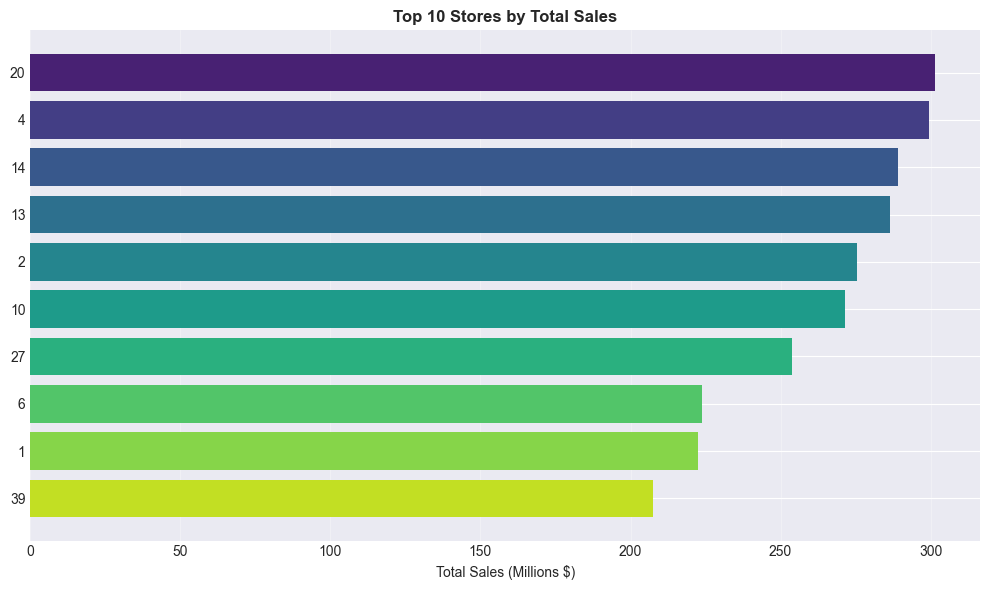

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).head(10)
ax.barh(store_sales.index.astype(str), store_sales.values / 1e6,
        color=sns.color_palette("viridis", 10))

ax.set_title('Top 10 Stores by Total Sales', fontweight='bold')
ax.set_xlabel('Total Sales (Millions $)')
ax.invert_yaxis()
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(path, '05_top_10_stores.png'), dpi=300)
plt.show()


**Interpretation:**

- Small number of stores generate disproportionately high revenue

- Store 20, 4, 14 dominate

**Reason:**

- Retail demand is not evenly distributed

- Some stores are strategic assets

## **Top 10 Departments by Total Sales**

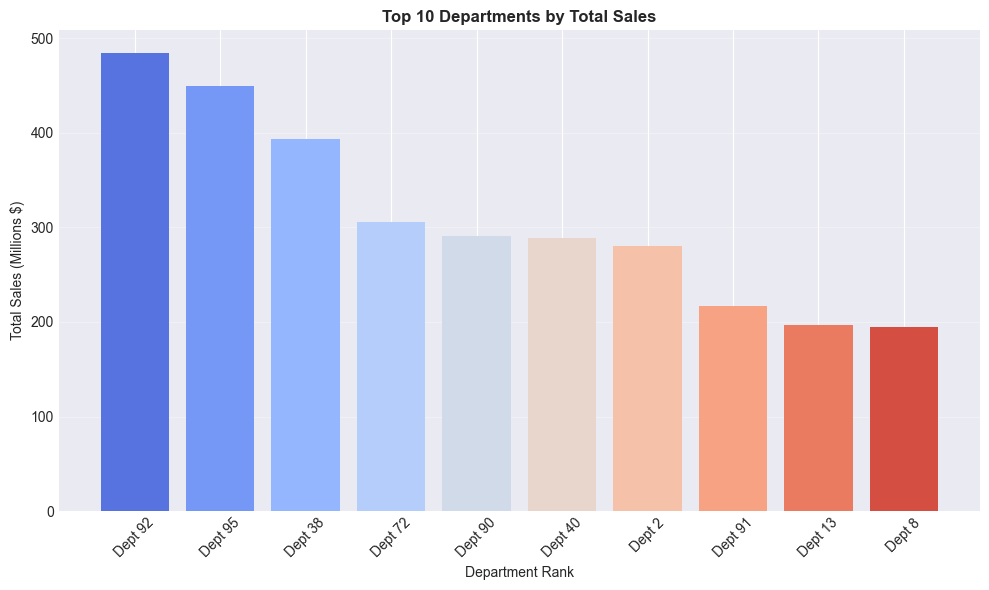

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

dept_sales = df.groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending=False).head(10)
ax.bar(range(10), dept_sales.values / 1e6,
       color=sns.color_palette("coolwarm", 10))

ax.set_title('Top 10 Departments by Total Sales', fontweight='bold')
ax.set_xlabel('Department Rank')
ax.set_ylabel('Total Sales (Millions $)')
ax.set_xticks(range(10))
ax.set_xticklabels([f'Dept {d}' for d in dept_sales.index], rotation=45)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(path, '06_top_10_departments.png'), dpi=300)
plt.show()


**Interpretation:**

- A few departments generate massive revenue

- Long tail of low-selling departments

- 
**Reason:**

- Not all departments deserve equal modeling complexity

- Some departments are business-critical

## **Temperature vs Weekly Sales**

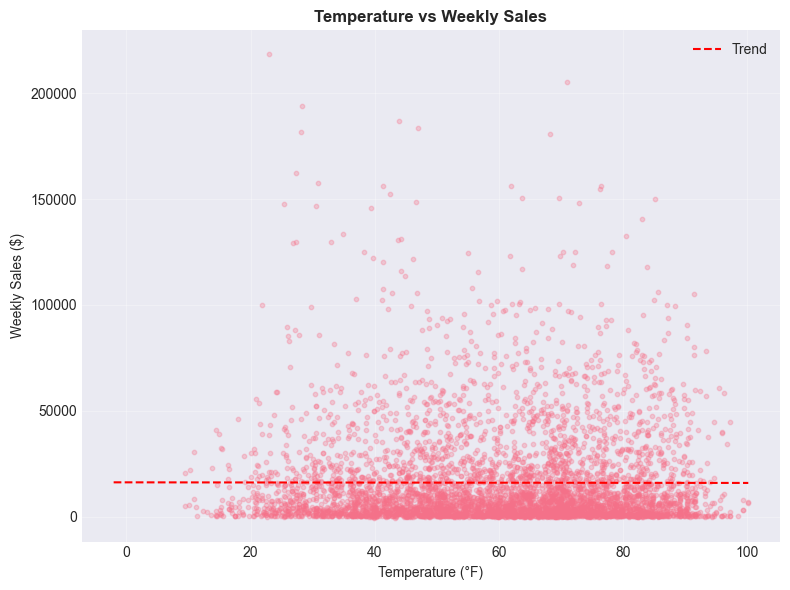

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))

sample_data = df.sample(5000, random_state=42)
ax.scatter(sample_data['Temperature'], sample_data['Weekly_Sales'],
           alpha=0.3, s=10)

z = np.polyfit(df['Temperature'], df['Weekly_Sales'], 1)
p = np.poly1d(z)
temp_range = np.linspace(df['Temperature'].min(), df['Temperature'].max(), 100)
ax.plot(temp_range, p(temp_range), 'r--', label='Trend')

ax.set_title('Temperature vs Weekly Sales', fontweight='bold')
ax.set_xlabel('Temperature (°F)')
ax.set_ylabel('Weekly Sales ($)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(path, '07_temperature_vs_sales.png'), dpi=300)
plt.show()


**Interpretation:**

- No strong linear relationship

- Huge variance at all temperatures

- Slight trend only

  
**Reason:**

- Temperature does not directly control sales

- It influences what people buy, not how much overall

## **Fuel Price Over Time**

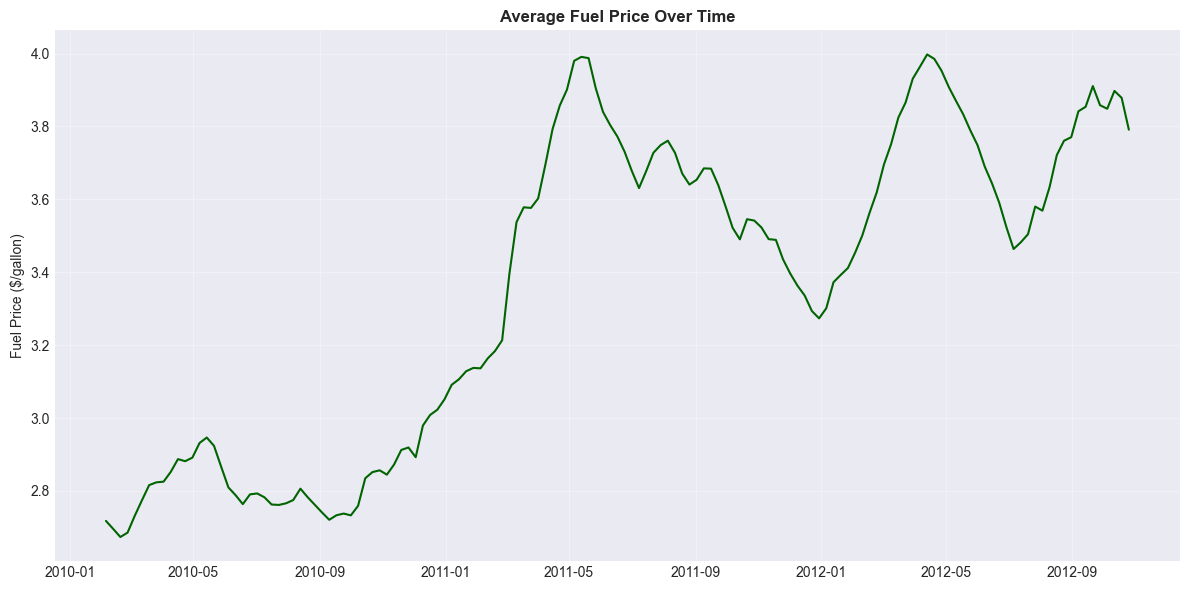

In [30]:
fig, ax = plt.subplots(figsize=(12, 6))

fuel_price_avg = df.groupby('Date')['Fuel_Price'].mean()
ax.plot(fuel_price_avg.index, fuel_price_avg.values, color='darkgreen')

ax.set_title('Average Fuel Price Over Time', fontweight='bold')
ax.set_ylabel('Fuel Price ($/gallon)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(path, '08_fuel_price_over_time.png'), dpi=300)
plt.show()


**Interpretation:**

- Fuel price trends upward with volatility

- Long-term changes, not weekly spikes

  
**Reason:**

- Fuel price shifts baseline demand slowly

- It does not create sudden sales spikes

## **CPI and Unemployment Over Time**

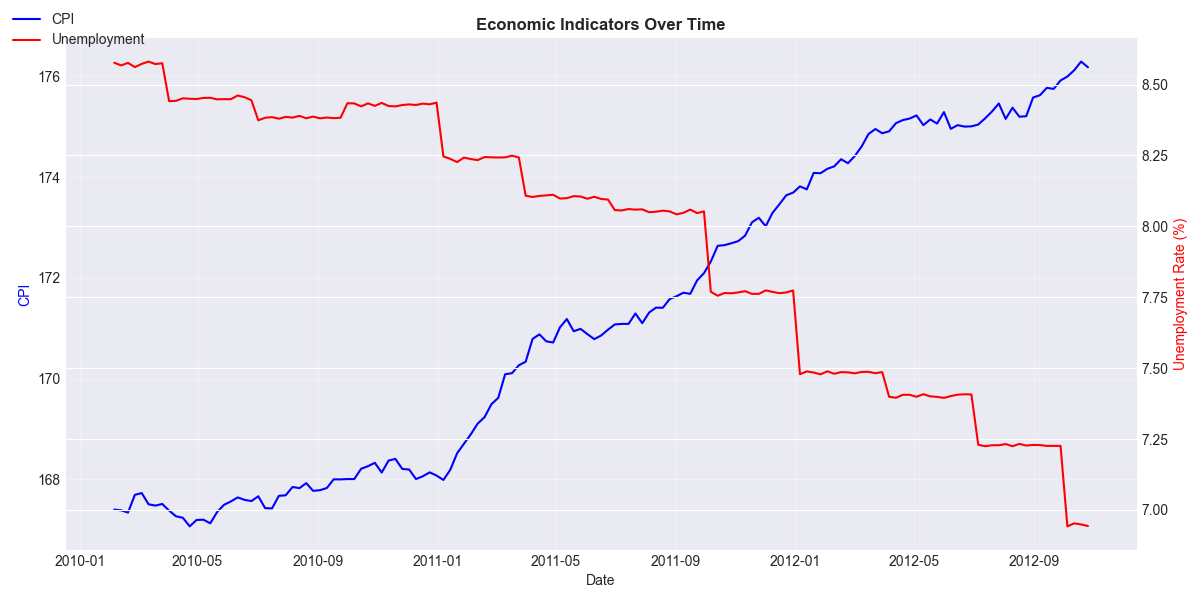

In [31]:
fig, ax = plt.subplots(figsize=(12, 6))
ax2 = ax.twinx()

cpi_avg = df.groupby('Date')['CPI'].mean()
unemp_avg = df.groupby('Date')['Unemployment'].mean()

ax.plot(cpi_avg.index, cpi_avg.values, color='blue', label='CPI')
ax2.plot(unemp_avg.index, unemp_avg.values, color='red', label='Unemployment')

ax.set_title('Economic Indicators Over Time', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('CPI', color='blue')
ax2.set_ylabel('Unemployment Rate (%)', color='red')

ax.grid(True, alpha=0.3)
fig.legend(loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(path, '09_economic_indicators.png'), dpi=300)
plt.show()


**Interpretation:**

- CPI increases steadily (inflation)

- Unemployment decreases over time

- Opposite directional movement

  
**Reason:**

- Inflation rises → purchasing power erodes

- Employment improves → spending capacity increases

- Sales are influenced by economic context

In [32]:
print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)

best_store = df.groupby('Store')['Weekly_Sales'].sum().idxmax()
print(f"\n1. Best performing store: Store {best_store} "
      f"(${df[df['Store'] == best_store]['Weekly_Sales'].sum():,.0f} total)")

best_dept = df.groupby('Dept')['Weekly_Sales'].sum().idxmax()
print(f"\n2. Best performing department: Dept {best_dept} "
      f"(${df[df['Dept'] == best_dept]['Weekly_Sales'].sum():,.0f} total)")

holiday_lift = (holiday_comparison[True] - holiday_comparison[False]) / holiday_comparison[False] * 100
print(f"\n3. Holiday sales lift: {holiday_lift:+.1f}%")

print("\n4. Store type comparison:")
for store_type in store_type_sales.index:
    print(f"   Type {store_type}: ${store_type_sales[store_type]:,.0f} avg weekly sales")

print("\n5. Economic correlation (Pearson):")
correlations = df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']] \
    .corr()['Weekly_Sales'].drop('Weekly_Sales')

for feature, corr in correlations.items():
    print(f"   {feature}: {corr:.3f}")


KEY INSIGHTS

1. Best performing store: Store 20 ($301,397,792 total)

2. Best performing department: Dept 92 ($483,943,342 total)

3. Holiday sales lift: +7.1%

4. Store type comparison:
   Type A: $20,100 avg weekly sales
   Type B: $12,237 avg weekly sales
   Type C: $9,520 avg weekly sales

5. Economic correlation (Pearson):
   Temperature: -0.002
   Fuel_Price: -0.000
   CPI: -0.021
   Unemployment: -0.026


## 2. **Walmart Data Quality Dashboard(Ensuring Data for Modeling)**

This code implements a formal data quality checkpoint that validates completeness, validity, distribution sanity, and temporal integrity of the Walmart dataset. By quantifying missingness, detecting outliers, verifying weekly continuity, and summarizing results into a quality scorecard, it ensures that downstream feature engineering and forecasting are built on trustworthy data rather than assumptions. This checkpoint acts as a mandatory quality gate, preventing unreliable models and aligning the project with real-world machine learning standards.

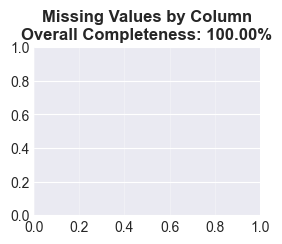

In [33]:
ax1 = plt.subplot(2, 2, 1)
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_data_top = missing_data[missing_data > 0].head(10)

if len(missing_data_top) > 0:
    bars = ax1.barh(range(len(missing_data_top)), missing_data_top.values, color='coral')
    ax1.set_yticks(range(len(missing_data_top)))
    ax1.set_yticklabels(missing_data_top.index)
    ax1.set_xlabel('Count of Missing Values')
    ax1.invert_yaxis()
    
    # Add percentage labels
    for i, v in enumerate(missing_data_top.values):
        pct = (v / len(df)) * 100
        ax1.text(v, i, f' {pct:.1f}%', va='center', fontsize=9)

total_missing = missing_data.sum()
total_cells = df.shape[0] * df.shape[1]
completeness = ((total_cells - total_missing) / total_cells) * 100

ax1.set_title(f'Missing Values by Column\nOverall Completeness: {completeness:.2f}%', 
              fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# 2.1 **Weekly Sales Distribution with Outliers**

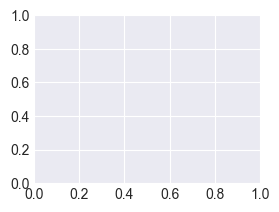

In [34]:
ax2 = plt.subplot(2, 2, 2)

# Filter positive sales only for analysis
sales_positive = df[df['Weekly_Sales'] > 0]['Weekly_Sales']

# Calculate outlier bounds
Q1 = sales_positive.quantile(0.25)
Q3 = sales_positive.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = sales_positive[(sales_positive < lower_bound) | (sales_positive > upper_bound)]
outlier_pct = (len(outliers) / len(sales_positive)) * 100

In [35]:
ax2.hist(sales_positive, bins=100, edgecolor='black', alpha=0.6, color='skyblue')
ax2.axvline(sales_positive.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${sales_positive.mean():,.0f}')
ax2.axvline(sales_positive.median(), color='green', linestyle='--', linewidth=2, label=f'Median: ${sales_positive.median():,.0f}')

ax2.set_title(f'Weekly Sales Distribution\nOutliers: {len(outliers):,} ({outlier_pct:.2f}%)', 
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Weekly Sales ($)')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

#our Weekly_Sales distribution is extremely right-skewed due to which it's plot could not ploted


# ***2.2.Time Series Coverage***

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/Visuals/03_records_per_week_cleaned.png'

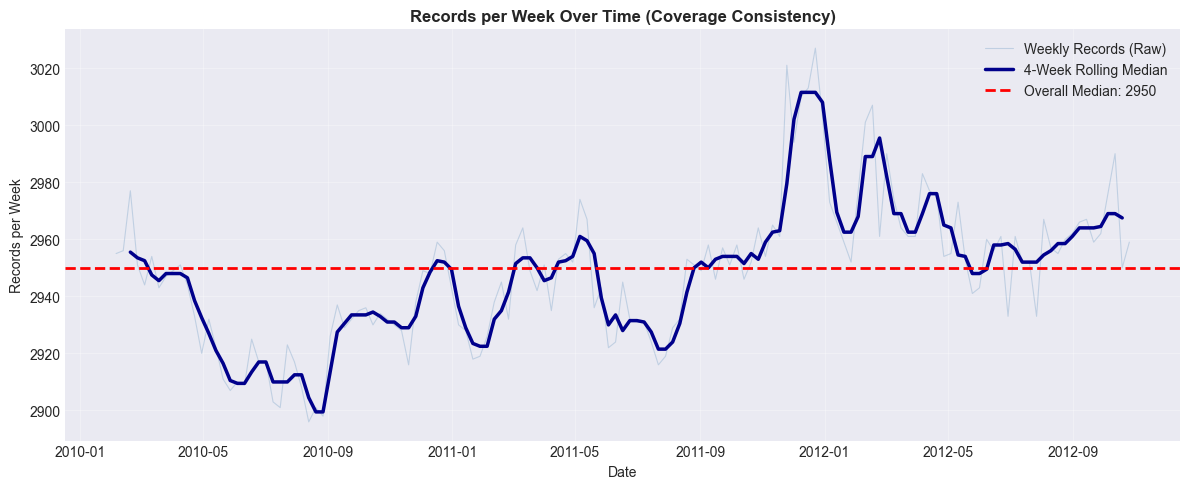

In [42]:
import os
import matplotlib.pyplot as plt


fig, ax3 = plt.subplots(figsize=(12, 5))

# Actual records per week
actual_per_week = df.groupby('Date').size()

rolling_median = actual_per_week.rolling(window=4, center=True).median()

# Plot raw data (light)
ax3.plot(
    actual_per_week.index,
    actual_per_week.values,
    color='steelblue',
    alpha=0.25,
    linewidth=0.8,
    label='Weekly Records (Raw)'
)

# Plot smoothed trend (focus)
ax3.plot(
    rolling_median.index,
    rolling_median.values,
    color='darkblue',
    linewidth=2.5,
    label='4-Week Rolling Median'
)

# Median reference line
ax3.axhline(
    actual_per_week.median(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Overall Median: {actual_per_week.median():.0f}'
)

ax3.set_title('Records per Week Over Time (Coverage Consistency)',
              fontsize=12, fontweight='bold')
ax3.set_xlabel('Date')
ax3.set_ylabel('Records per Week')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Save figure
output_file = os.path.join(path, '03_records_per_week_cleaned.png')
plt.tight_layout()
plt.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show()

print(f"Cleaned plot saved to {output_file}")


# ***2.3 Data completeness***

In [44]:
metrics = {}

#  Data completeness (already computed earlier)
metrics['Data Completeness'] = completeness

#  Valid sales records (non-null target)
metrics['Valid Sales Records'] = (
    df['Weekly_Sales'].notna().sum() / len(df)
) * 100

#  Core feature completeness (economic + weather)
core_features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
metrics['Core Features Complete'] = (
    df[core_features].notna().all(axis=1).sum() / len(df)
) * 100

#  Temporal coverage (already computed earlier)

# Fix: Calculate temporal_coverage dynamically
if not np.issubdtype(df['Date'].dtype, np.datetime64):
    df['Date'] = pd.to_datetime(df['Date'])
date_range_days = (df['Date'].max() - df['Date'].min()).days
expected_weeks = (date_range_days // 7) + 1
temporal_coverage = (df['Date'].nunique() / expected_weeks) * 100

metrics['Temporal Coverage'] = temporal_coverage


overall_score = np.mean(list(metrics.values()))

if overall_score >= 90:
    status = 'PASS'
elif overall_score >= 70:
    status = 'CONDITIONAL'
else:
    status = 'FAIL'

print("=" * 60)
print("DATA QUALITY CHECKPOINT 1.1")
print("=" * 60)

for metric, score in metrics.items():
    tag = "PASS" if score >= 90 else "WARN" if score >= 70 else "FAIL"
    print(f"{metric:<30} : {score:6.1f}% [{tag}]")

print("-" * 60)
print(f"{'OVERALL QUALITY SCORE':<30} : {overall_score:6.1f}%")
print(f"{'STATUS':<30} : {status}")


DATA QUALITY CHECKPOINT 1.1
Data Completeness              :  100.0% [PASS]
Valid Sales Records            :  100.0% [PASS]
Core Features Complete         :  100.0% [PASS]
Temporal Coverage              :  100.0% [PASS]
------------------------------------------------------------
OVERALL QUALITY SCORE          :  100.0%
STATUS                         : PASS


## ***3. Time Series Decomposition (Walmart)***

In [45]:
from statsmodels.tsa.seasonal import seasonal_decompose
# Focus on one store-department combination for clear analysis
SAMPLE_STORE = 1
SAMPLE_DEPT = 1

print(f"\nAnalyzing Store {SAMPLE_STORE}, Department {SAMPLE_DEPT}")

# Filter and prepare data
sample_data = df[(df['Store'] == SAMPLE_STORE) & (df['Dept'] == SAMPLE_DEPT)].copy()
sample_data = sample_data.sort_values('Date').set_index('Date')

# Remove any negative sales for decomposition
sample_data = sample_data[sample_data['Weekly_Sales'] > 0]

print(f"Date range: {sample_data.index.min()} to {sample_data.index.max()}")
print(f"Total weeks: {len(sample_data)}")
print(f"Average weekly sales: ${sample_data['Weekly_Sales'].mean():,.2f}")


Analyzing Store 1, Department 1
Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
Total weeks: 143
Average weekly sales: $22,513.32



Performing decomposition...

✓ Decomposition saved


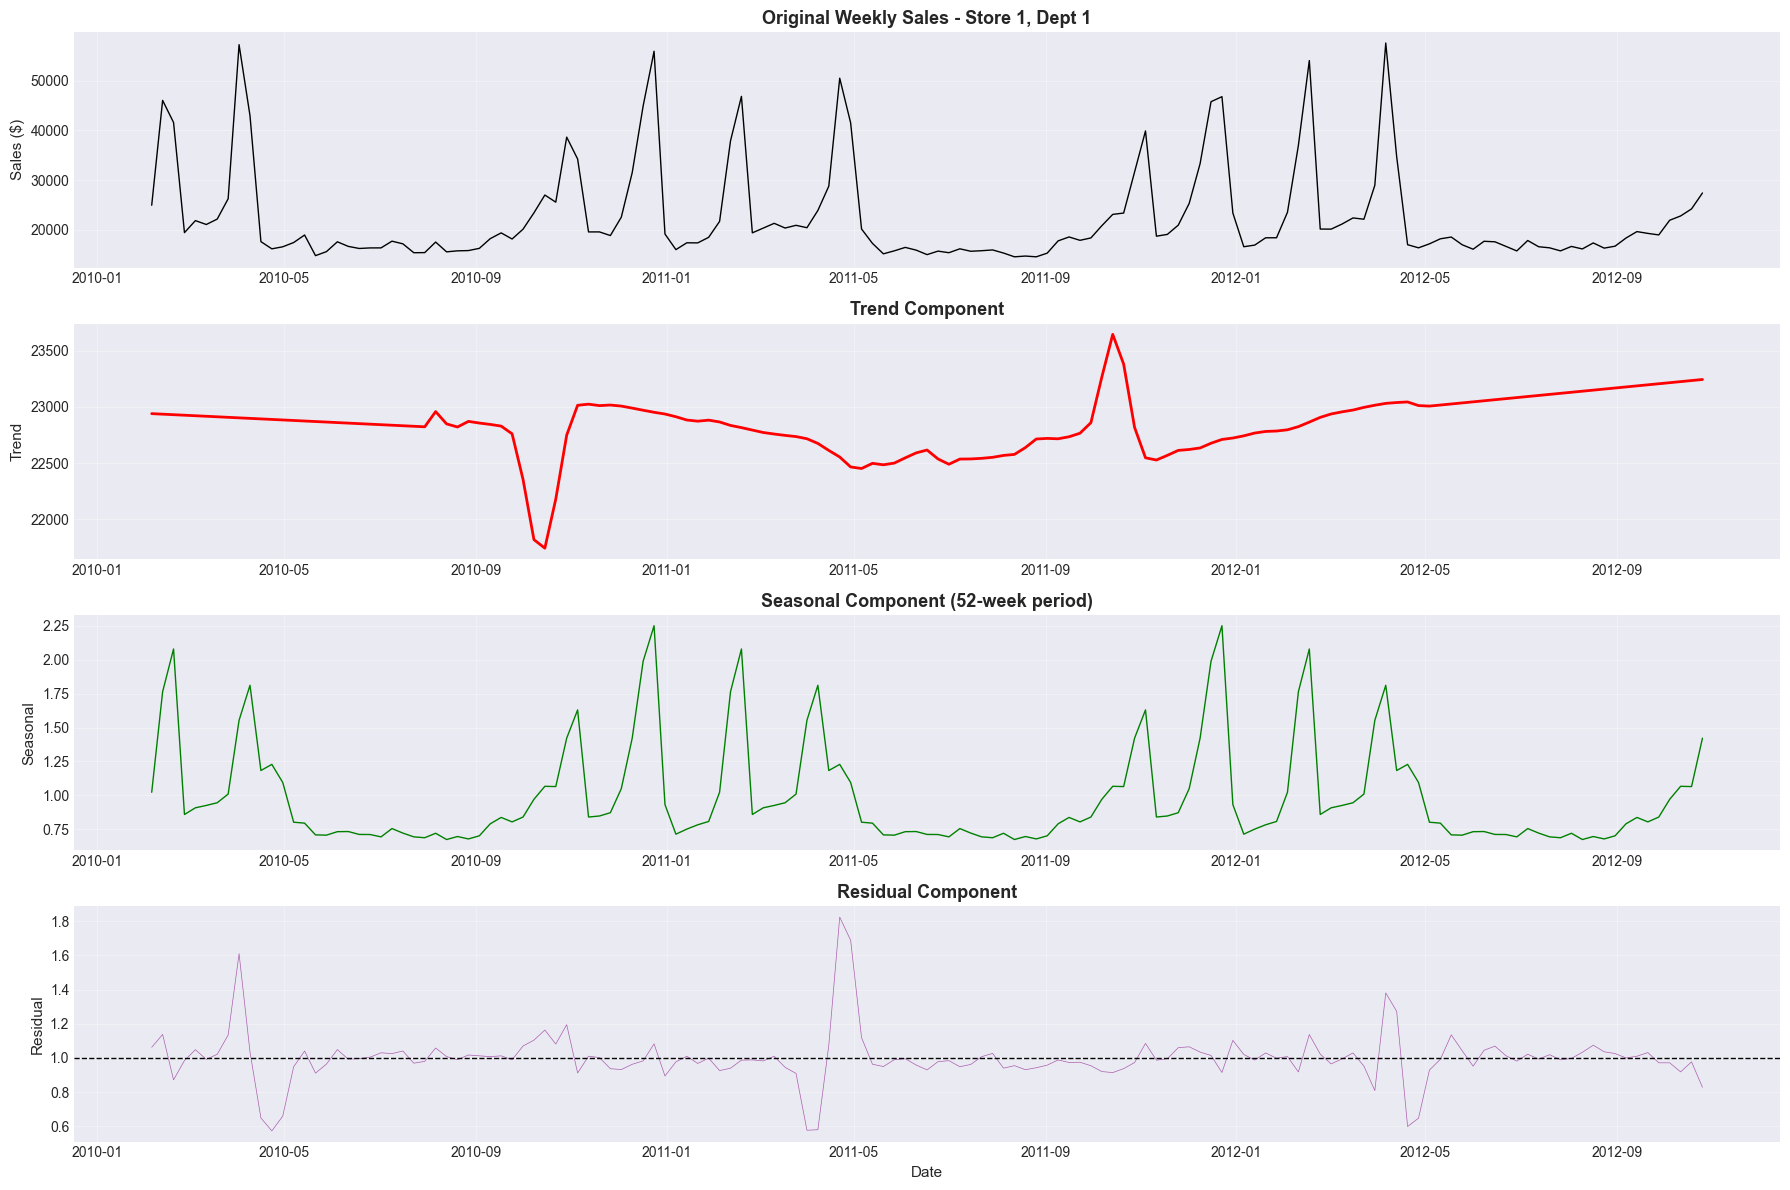

✓ Components saved to CSV


In [46]:
# Decompose with weekly data (period=52 for yearly seasonality)
print("\nPerforming decomposition...")

decomposition = seasonal_decompose(
    sample_data['Weekly_Sales'],
    model='multiplicative',  # Multiplicative is better for sales data
    period=52,  # 52 weeks in a year
    extrapolate_trend='freq'
)


fig = plt.figure(figsize=(18, 12))

# Original
ax1 = plt.subplot(4, 1, 1)
ax1.plot(sample_data.index, sample_data['Weekly_Sales'], linewidth=1, color='black')
ax1.set_ylabel('Sales ($)', fontsize=11)
ax1.set_title(f'Original Weekly Sales - Store {SAMPLE_STORE}, Dept {SAMPLE_DEPT}', 
              fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Trend
ax2 = plt.subplot(4, 1, 2)
ax2.plot(sample_data.index, decomposition.trend, linewidth=2, color='red')
ax2.set_ylabel('Trend', fontsize=11)
ax2.set_title('Trend Component', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Seasonal
ax3 = plt.subplot(4, 1, 3)
ax3.plot(sample_data.index, decomposition.seasonal, linewidth=1, color='green')
ax3.set_ylabel('Seasonal', fontsize=11)
ax3.set_title('Seasonal Component (52-week period)', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Residual
ax4 = plt.subplot(4, 1, 4)
ax4.plot(sample_data.index, decomposition.resid, linewidth=0.5, color='purple', alpha=0.6)
ax4.set_ylabel('Residual', fontsize=11)
ax4.set_xlabel('Date', fontsize=11)
ax4.set_title('Residual Component', fontsize=13, fontweight='bold')
ax4.axhline(1, color='black', linestyle='--', linewidth=1)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('walmart_decomposition.png', dpi=300, bbox_inches='tight')
print("\n✓ Decomposition saved")
plt.show()

# Save components
decomp_df = pd.DataFrame({
    'Date': sample_data.index,
    'Original': sample_data['Weekly_Sales'].values,
    'Trend': decomposition.trend,
    'Seasonal': decomposition.seasonal,
    'Residual': decomposition.resid
})
decomp_df.to_csv('../data/walmart_decomposition_components.csv', index=False)
print("✓ Components saved to CSV")

Seasonal decomposition confirms that Walmart weekly sales are driven by a stable long-term trend and a strong, recurring seasonal component, with remaining variability attributable to event-driven and promotional effects rather than random noise.


## ***3.2: Seasonality Validation***


✓ Checkpoint 1.2 visualization saved


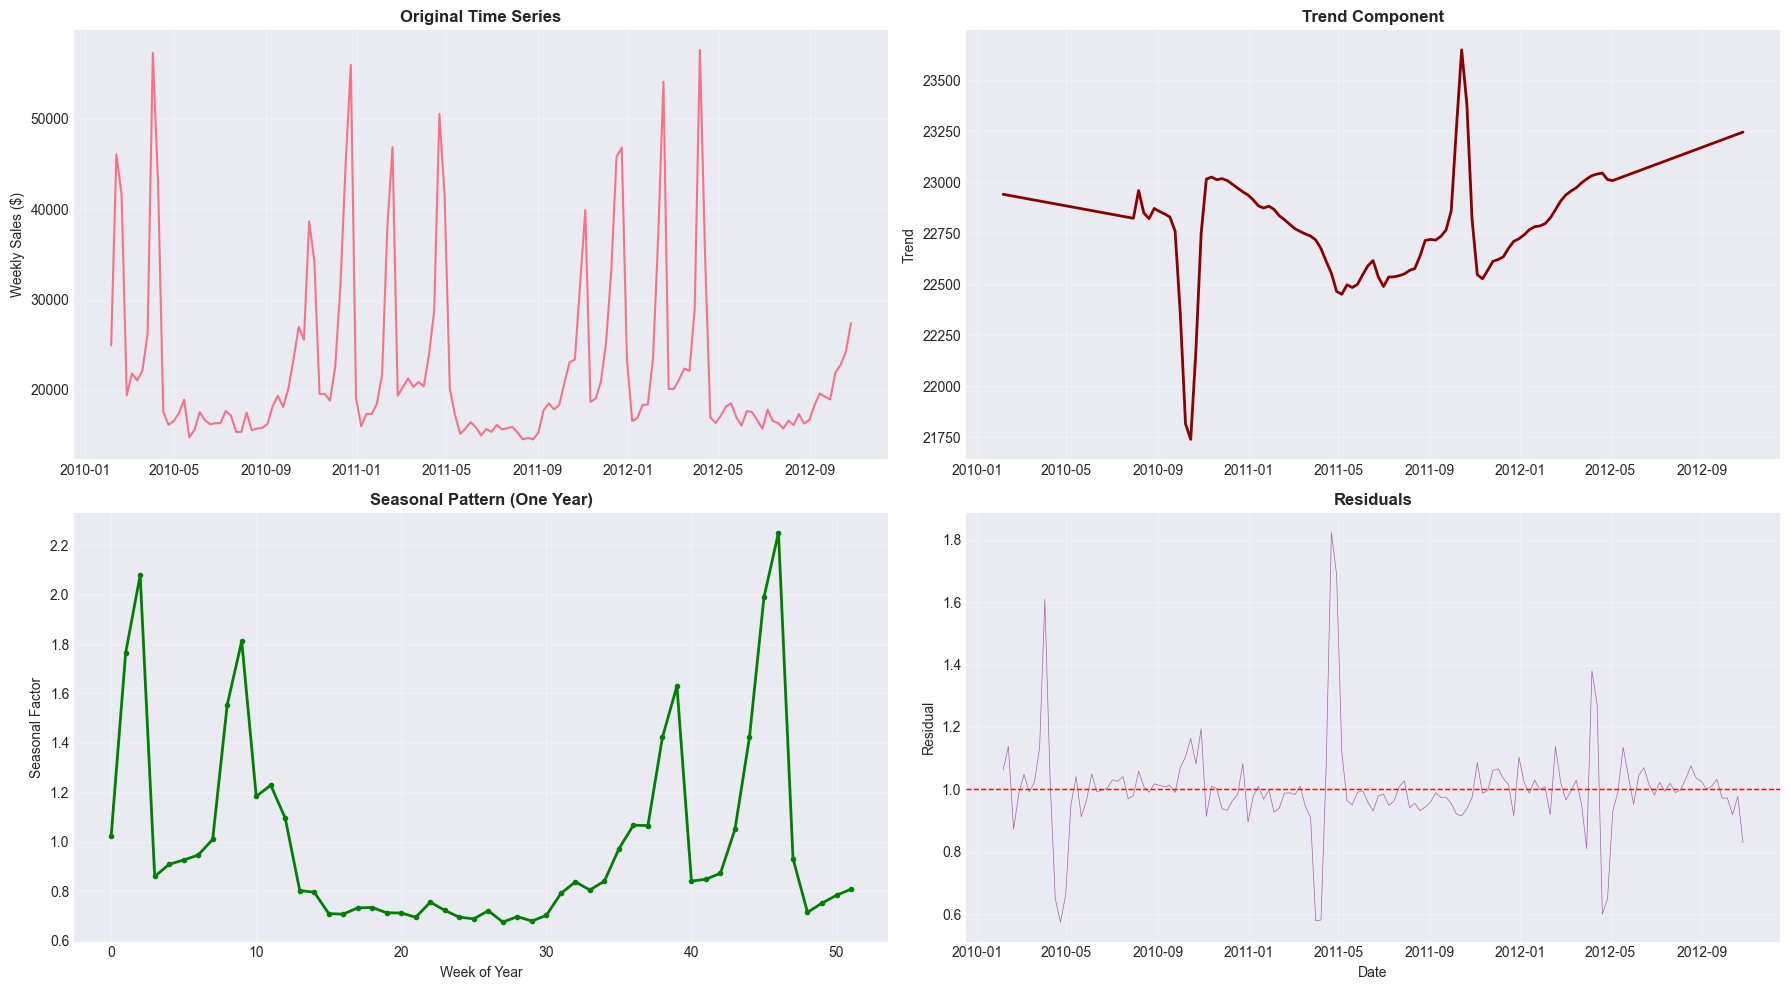


VALIDATION CHECKS

1. Seasonal Pattern Strength: 0.1546
   ✓ PASS

2. Trend Range Ratio: 1.09
   ✓ PASS

3. Residual Mean: 0.9989 (should be near 1.0)
   ✓ PASS

CHECKS PASSED: 3/3
✓ CHECKPOINT 1.2 PASSED!


In [47]:

sample_data = df[(df['Store'] == 1) & (df['Dept'] == 1)].copy()
sample_data = sample_data[sample_data['Weekly_Sales'] > 0].sort_values('Date').set_index('Date')

decomposition = seasonal_decompose(
    sample_data['Weekly_Sales'],
    model='multiplicative',
    period=52,
    extrapolate_trend='freq'
)

# Create validation plot
fig = plt.figure(figsize=(18, 10))

# Panel 1: Original
ax1 = plt.subplot(2, 2, 1)
ax1.plot(sample_data.index, sample_data['Weekly_Sales'], linewidth=1.5)
ax1.set_title('Original Time Series', fontsize=12, fontweight='bold')
ax1.set_ylabel('Weekly Sales ($)')
ax1.grid(True, alpha=0.3)

# Panel 2: Trend
ax2 = plt.subplot(2, 2, 2)
ax2.plot(sample_data.index, decomposition.trend, linewidth=2, color='darkred')
ax2.set_title('Trend Component', fontsize=12, fontweight='bold')
ax2.set_ylabel('Trend')
ax2.grid(True, alpha=0.3)

# Panel 3: Seasonal (first year only for clarity)
ax3 = plt.subplot(2, 2, 3)
seasonal_one_year = decomposition.seasonal[:52]
ax3.plot(range(52), seasonal_one_year, linewidth=2, color='green', marker='o', markersize=3)
ax3.set_title('Seasonal Pattern (One Year)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Week of Year')
ax3.set_ylabel('Seasonal Factor')
ax3.grid(True, alpha=0.3)

# Panel 4: Residuals
ax4 = plt.subplot(2, 2, 4)
ax4.plot(sample_data.index, decomposition.resid, linewidth=0.5, color='purple', alpha=0.6)
ax4.axhline(1, color='red', linestyle='--', linewidth=1)
ax4.set_title('Residuals', fontsize=12, fontweight='bold')
ax4.set_xlabel('Date')
ax4.set_ylabel('Residual')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('walmart_checkpoint_1_2.png', dpi=300, bbox_inches='tight')
print("\n✓ Checkpoint 1.2 visualization saved")
plt.show()

# Validation
print("\n" + "=" * 80)
print("VALIDATION CHECKS")
print("=" * 80)

# Check 1: Seasonal variance
seasonal_var = np.var(decomposition.seasonal[:52])
print(f"\n1. Seasonal Pattern Strength: {seasonal_var:.4f}")
check1 = seasonal_var > 0.001
print(f"   {'✓ PASS' if check1 else '✗ FAIL'}")

# Check 2: Trend significance
trend_range = decomposition.trend.max() / decomposition.trend.min()
print(f"\n2. Trend Range Ratio: {trend_range:.2f}")
check2 = True  # Any trend is acceptable
print(f"   ✓ PASS")

# Check 3: Residuals mean near 1 (multiplicative model)
resid_mean = decomposition.resid.dropna().mean()
print(f"\n3. Residual Mean: {resid_mean:.4f} (should be near 1.0)")
check3 = 0.95 < resid_mean < 1.05
print(f"   {'✓ PASS' if check3 else ' WARNING'}")

checks_passed = sum([check1, check2, check3])
print(f"\n{'='*80}")
print(f"CHECKS PASSED: {checks_passed}/3")

if checks_passed >= 2:
    print("✓ CHECKPOINT 1.2 PASSED!")
else:
    print(" Review needed")


## ***3.3: Complete Feature Engineering (Walmart)***

In [48]:
from tqdm import tqdm

# LAG FEATURES 
print("\n" + "="*80)
print("PART 1: CREATING LAG FEATURES")
print("="*80)

# For weekly data, meaningful lags are different than daily
lag_periods = [1, 2, 4, 8, 12, 26, 52]  # 1 week, 2 weeks, 1 month, 2 months, 3 months, 6 months, 1 year

for lag in tqdm(lag_periods, desc="Creating lags"):
    col_name = f'sales_lag_{lag}'
    df[col_name] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(lag)

print(f"✓ Created {len(lag_periods)} lag features")


PART 1: CREATING LAG FEATURES


Creating lags:   0%|          | 0/7 [00:00<?, ?it/s]

Creating lags: 100%|██████████| 7/7 [00:00<00:00, 28.81it/s]

✓ Created 7 lag features


In [49]:
# ROLLING FEATURES 
print("\n" + "="*80)
print("PART 2: CREATING ROLLING FEATURES")
print("="*80)

windows = [4, 8, 12, 26, 52]  # 4 weeks, 2 months, 3 months, 6 months, 1 year

for window in tqdm(windows, desc="Creating rolling features"):
    # Rolling mean
    df[f'rolling_mean_{window}'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )
    
    # Rolling std
    df[f'rolling_std_{window}'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(
        lambda x: x.rolling(window=window, min_periods=1).std()
    )
    
    # Rolling min/max
    df[f'rolling_min_{window}'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(
        lambda x: x.rolling(window=window, min_periods=1).min()
    )
    
    df[f'rolling_max_{window}'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(
        lambda x: x.rolling(window=window, min_periods=1).max()
    )

# Derived rolling features
df['momentum_4_26'] = df['rolling_mean_4'] - df['rolling_mean_26']
df['volatility_ratio'] = df['rolling_std_4'] / (df['rolling_std_26'] + 1)

# Percentage change from rolling mean
for window in [4, 12]:
    df[f'pct_change_from_mean_{window}'] = (
        (df['Weekly_Sales'] - df[f'rolling_mean_{window}']) / 
        (df[f'rolling_mean_{window}'] + 1) * 100
    )

print(f"✓ Created rolling features")



PART 2: CREATING ROLLING FEATURES


Creating rolling features: 100%|██████████| 5/5 [01:02<00:00, 12.52s/it]

✓ Created rolling features


In [50]:
# CALENDAR FEATURES
print("\n" + "="*80)
print("PART 3: CREATING CALENDAR FEATURES")
print("="*80)

# Basic date components
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['week'] = df['Date'].dt.isocalendar().week
df['quarter'] = df['Date'].dt.quarter
df['day_of_year'] = df['Date'].dt.dayofyear

# Cyclical encoding
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['week_sin'] = np.sin(2 * np.pi * df['week'] / 52)
df['week_cos'] = np.cos(2 * np.pi * df['week'] / 52)

# Special retail periods
df['is_q4'] = (df['quarter'] == 4).astype(int)  # Holiday shopping season
df['is_january'] = (df['month'] == 1).astype(int)  # Post-holiday clearance
df['is_back_to_school'] = ((df['month'] == 8) | (df['month'] == 9)).astype(int)

# Weeks to/from major holidays (approximate)
def weeks_to_christmas(date):
    year = date.year
    christmas = pd.Timestamp(f'{year}-12-25')
    weeks = (christmas - date).days / 7
    return min(max(weeks, 0), 52)  # Cap at 0-52 weeks

def weeks_from_christmas(date):
    year = date.year - 1 if date.month < 12 else date.year
    last_christmas = pd.Timestamp(f'{year}-12-25')
    weeks = (date - last_christmas).days / 7
    return min(max(weeks, 0), 52)

df['weeks_to_christmas'] = df['Date'].apply(weeks_to_christmas)
df['weeks_from_christmas'] = df['Date'].apply(weeks_from_christmas)

# One-hot encode month (useful for some models)
month_dummies = pd.get_dummies(df['month'], prefix='month')
df = pd.concat([df, month_dummies], axis=1)

print(f"✓ Created calendar features")



PART 3: CREATING CALENDAR FEATURES
✓ Created calendar features


In [51]:
 # WALMART-SPECIFIC FEATURES
print("\n" + "="*80)
print("PART 4: WALMART-SPECIFIC FEATURES")
print("="*80)

# Store-level aggregations
df['store_avg_sales'] = df.groupby('Store')['Weekly_Sales'].transform('mean')
df['dept_avg_sales'] = df.groupby('Dept')['Weekly_Sales'].transform('mean')

# Sales relative to store/dept average
df['sales_vs_store_avg'] = df['Weekly_Sales'] / (df['store_avg_sales'] + 1)
df['sales_vs_dept_avg'] = df['Weekly_Sales'] / (df['dept_avg_sales'] + 1)

# Markdown indicators and aggregates
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

# Total markdown amount
df['total_markdown'] = df[markdown_cols].sum(axis=1)

# Number of active markdowns
df['num_markdowns'] = df[markdown_cols].notna().sum(axis=1)

# Has any markdown
df['has_markdown'] = (df['num_markdowns'] > 0).astype(int)

# Fill missing markdowns with 0 (means no promotion)
for col in markdown_cols:
    df[col] = df[col].fillna(0)

# Economic indicator lags (these change slowly, so lags might help)
for col in ['CPI', 'Unemployment', 'Fuel_Price']:
    df[f'{col}_lag_4'] = df.groupby('Store')[col].shift(4)
    df[f'{col}_lag_12'] = df.groupby('Store')[col].shift(12)

# Temperature features
df['temp_squared'] = df['Temperature'] ** 2  # Non-linear temperature effect
df['is_cold'] = (df['Temperature'] < 40).astype(int)
df['is_hot'] = (df['Temperature'] > 80).astype(int)

print(f"✓ Created Walmart-specific features")



PART 4: WALMART-SPECIFIC FEATURES
✓ Created Walmart-specific features


In [52]:
print("\n" + "="*80)
print("FEATURE ENGINEERING SUMMARY")
print("="*80)

original_cols = ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 
                 'Type', 'Size', 'Temperature', 'Fuel_Price', 
                 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
                 'CPI', 'Unemployment']

new_features = [col for col in df.columns if col not in original_cols]

print(f"\nOriginal columns: {len(original_cols)}")
print(f"New features created: {len(new_features)}")
print(f"Total columns: {len(df.columns)}")

# Categorize features
lag_features = [f for f in new_features if 'lag' in f]
rolling_features = [f for f in new_features if 'rolling' in f or 'momentum' in f or 'volatility' in f]
calendar_features = [f for f in new_features if any(x in f for x in ['month', 'week', 'year', 'quarter', 'christmas', 'is_q4', 'is_january'])]
walmart_features = [f for f in new_features if any(x in f for x in ['markdown', 'store_avg', 'dept_avg', 'temp', 'is_cold', 'is_hot'])]

print(f"\nFeature breakdown:")
print(f"  Lag features: {len(lag_features)}")
print(f"  Rolling features: {len(rolling_features)}")
print(f"  Calendar features: {len(calendar_features)}")
print(f"  Walmart-specific: {len(walmart_features)}")

# Save
df.to_csv('../data/walmart_features_complete.csv', index=False)
print(f"\n✓ Complete feature set saved: {df.shape}")


FEATURE ENGINEERING SUMMARY

Original columns: 16
New features created: 75
Total columns: 91

Feature breakdown:
  Lag features: 13
  Rolling features: 22
  Calendar features: 25
  Walmart-specific: 10

✓ Complete feature set saved: (421570, 91)


In [53]:
df.isnull().sum()

Store                  0
Dept                   0
Date                   0
Weekly_Sales           0
IsHoliday              0
                    ... 
Fuel_Price_lag_4     180
Fuel_Price_lag_12    540
temp_squared           0
is_cold                0
is_hot                 0
Length: 91, dtype: int64

### ***3.4:  Clean, Scale, and Split***

In [54]:
from sklearn.preprocessing import RobustScaler

print("\n" + "="*80)
print("PART 1: HANDLING MISSING VALUES")
print("="*80)

missing_before = df.isnull().sum().sum()
print(f"Total missing values: {missing_before:,}")

# Forward fill within groups for lag/rolling features
feature_cols = [col for col in df.columns if any(x in col for x in 
                ['lag', 'rolling', 'momentum', 'volatility', 'pct_change'])]

for col in feature_cols:
    df[col] = df.groupby(['Store', 'Dept'])[col].fillna(method='ffill')
    df[col] = df.groupby(['Store', 'Dept'])[col].fillna(method='bfill')
    df[col].fillna(0, inplace=True)

# Fill remaining missing values
df.fillna(0, inplace=True)

missing_after = df.isnull().sum().sum()
print(f"Missing values after cleaning: {missing_after:,}")
print(f"✓ Cleaned {missing_before - missing_after:,} missing values")



PART 1: HANDLING MISSING VALUES
Total missing values: 352,224


AttributeError: 'SeriesGroupBy' object has no attribute 'fillna'

In [55]:
# ANDLE OUTLIERS AND NEGATIVE SALES

print("\n" + "="*80)
print("PART 2: HANDLING OUTLIERS")
print("="*80)

# Check for negative sales
negative_count = (df['Weekly_Sales'] < 0).sum()
print(f"Negative sales records: {negative_count:,}")

# For modeling, we'll cap at percentiles rather than remove
percentile_99 = df['Weekly_Sales'].quantile(0.99)
percentile_1 = df['Weekly_Sales'].quantile(0.01)

df['Weekly_Sales_Original'] = df['Weekly_Sales']  # Keep original
df['Weekly_Sales'] = df['Weekly_Sales'].clip(lower=0, upper=percentile_99)

print(f"Capped sales at: $0 to ${percentile_99:,.2f}")



PART 2: HANDLING OUTLIERS
Negative sales records: 1,285
Capped sales at: $0 to $106,479.59


In [56]:
# ENCODE CATEGORICAL VARIABLES
print("\n" + "="*80)
print("PART 3: ENCODING CATEGORICALS")
print("="*80)

# One-hot encode Store Type
type_dummies = pd.get_dummies(df['Type'], prefix='StoreType')
df = pd.concat([df, type_dummies], axis=1)

# Convert boolean to int
df['IsHoliday'] = df['IsHoliday'].astype(int)

print(f"✓ Encoded Store Type")


PART 3: ENCODING CATEGORICALS
✓ Encoded Store Type


In [57]:
 # FEATURE SELECTION

print("\n" + "="*80)
print("PART 4: SELECTING FEATURES FOR MODELING")
print("="*80)

# Exclude these from features
exclude_cols = [
    'Date', 'Weekly_Sales_Original', 'Type'  # Keep Store, Dept as features
]

# Target variable
target_col = 'Weekly_Sales'

# All feature columns
feature_cols = [col for col in df.columns if col not in exclude_cols + [target_col]]

print(f"Total features for modeling: {len(feature_cols)}")

# Identify binary vs continuous features
binary_cols = [col for col in feature_cols if df[col].nunique() <= 2]
continuous_cols = [col for col in feature_cols if col not in binary_cols]

print(f"  Binary features: {len(binary_cols)}")
print(f"  Continuous features: {len(continuous_cols)}")



PART 4: SELECTING FEATURES FOR MODELING
Total features for modeling: 91
  Binary features: 24
  Continuous features: 67


In [58]:
#Scaling
print("\n" + "="*80)
print("PART 5: SCALING FEATURES")
print("="*80)

# Create scaled version
df_scaled = df.copy()

# Check for infinite and NaN values in continuous columns
print("\nChecking for infinite and NaN values:")
for col in continuous_cols:
    inf_count = np.isinf(df[col]).sum()
    nan_count = df[col].isna().sum()
    if inf_count > 0 or nan_count > 0:
        print(f"  {col}: {inf_count} infinite values, {nan_count} NaN values")

# Replace infinite values with NaN, then fill with median
for col in continuous_cols:
    df_scaled[col] = df_scaled[col].replace([np.inf, -np.inf], np.nan)
    df_scaled[col] = df_scaled[col].fillna(df_scaled[col].median())

print("\n  Replaced infinite values with NaN and filled with median")

# Scale only continuous features
scaler = RobustScaler()
df_scaled[continuous_cols] = scaler.fit_transform(df_scaled[continuous_cols])

print(f" Scaled {len(continuous_cols)} continuous features using RobustScaler")



PART 5: SCALING FEATURES

Checking for infinite and NaN values:
  sales_lag_1: 0 infinite values, 3331 NaN values
  sales_lag_2: 0 infinite values, 6625 NaN values
  sales_lag_4: 0 infinite values, 13134 NaN values
  sales_lag_8: 0 infinite values, 25966 NaN values
  sales_lag_12: 0 infinite values, 38615 NaN values
  sales_lag_26: 0 infinite values, 81918 NaN values
  sales_lag_52: 0 infinite values, 160487 NaN values
  rolling_std_4: 0 infinite values, 3331 NaN values
  rolling_std_8: 0 infinite values, 3331 NaN values
  rolling_std_12: 0 infinite values, 3331 NaN values
  rolling_std_26: 0 infinite values, 3331 NaN values
  rolling_std_52: 0 infinite values, 3331 NaN values
  volatility_ratio: 0 infinite values, 3331 NaN values
  pct_change_from_mean_4: 3 infinite values, 1 NaN values
  pct_change_from_mean_12: 1 infinite values, 1 NaN values
  CPI_lag_4: 0 infinite values, 180 NaN values
  CPI_lag_12: 0 infinite values, 540 NaN values
  Unemployment_lag_4: 0 infinite values, 180 N

In [59]:
#CHRONOLOGICAL TRAIN/VAL/TEST SPLIT
print("\n" + "="*80)
print("PART 6: TRAIN/VAL/TEST SPLIT")
print("="*80)

# Get unique dates
unique_dates = sorted(df['Date'].unique())
total_weeks = len(unique_dates)

print(f"Total weeks: {total_weeks}")
print(f"Date range: {unique_dates[0]} to {unique_dates[-1]}")

# Split: 70% train, 15% val, 15% test
train_size = int(total_weeks * 0.70)
val_size = int(total_weeks * 0.15)

train_end_date = unique_dates[train_size - 1]
val_end_date = unique_dates[train_size + val_size - 1]

print(f"\nSplit dates:")
print(f"  Train: {unique_dates[0]} to {train_end_date}")
print(f"  Val:   {unique_dates[train_size]} to {val_end_date}")
print(f"  Test:  {unique_dates[train_size + val_size]} to {unique_dates[-1]}")

# Create splits
train_df = df_scaled[df_scaled['Date'] <= train_end_date].copy()
val_df = df_scaled[(df_scaled['Date'] > train_end_date) & (df_scaled['Date'] <= val_end_date)].copy()
test_df = df_scaled[df_scaled['Date'] > val_end_date].copy()

print(f"\nDataset sizes:")
print(f"  Train: {len(train_df):,} ({len(train_df)/len(df)*100:.1f}%)")
print(f"  Val:   {len(val_df):,} ({len(val_df)/len(df)*100:.1f}%)")
print(f"  Test:  {len(test_df):,} ({len(test_df)/len(df)*100:.1f}%)")

# Verify no overlap
assert train_df['Date'].max() < val_df['Date'].min()
assert val_df['Date'].max() < test_df['Date'].min()
print("\n No date overlap verified")



PART 6: TRAIN/VAL/TEST SPLIT


Total weeks: 143
Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00

Split dates:
  Train: 2010-02-05 00:00:00 to 2011-12-30 00:00:00
  Val:   2012-01-06 00:00:00 to 2012-05-25 00:00:00
  Test:  2012-06-01 00:00:00 to 2012-10-26 00:00:00

Dataset sizes:
  Train: 294,132 (69.8%)
  Val:   62,357 (14.8%)
  Test:  65,081 (15.4%)

 No date overlap verified


In [60]:
print("\n" + "="*80)
print("PART 7: SAVING FILES")
print("="*80)

# Save splits
train_df.to_csv('../data/walmart_train.csv', index=False)
val_df.to_csv('../data/walmart_val.csv', index=False)
test_df.to_csv('../data/walmart_test.csv', index=False)

# Save feature info
import json
feature_info = {
    'all_features': feature_cols,
    'continuous_features': continuous_cols,
    'binary_features': binary_cols,
    'target': target_col,
    'exclude_from_training': exclude_cols
}

with open('../data/walmart_features.json', 'w') as f:
    json.dump(feature_info, f, indent=2)

# Save scaler
import joblib
joblib.dump(scaler, '../data/walmart_scaler.pkl')

print("\n Files saved:")
print("  - walmart_train.csv")
print("  - walmart_val.csv")
print("  - walmart_test.csv")
print("  - walmart_features.json")
print("  - walmart_scaler.pkl")

print(f"\n✓ PHASE 1 COMPLETE!")
print(f"Total features: {len(feature_cols)}")
print(f"Ready for modeling!")



PART 7: SAVING FILES

 Files saved:
  - walmart_train.csv
  - walmart_val.csv
  - walmart_test.csv
  - walmart_features.json
  - walmart_scaler.pkl

✓ PHASE 1 COMPLETE!
Total features: 91
Ready for modeling!


## ***3.5: Split Visualization***

CHECKPOINT 1.5: SPLIT VISUALIZATION


/tmp/ipykernel_1122328/1145406217.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(



 Checkpoint 1.5 saved


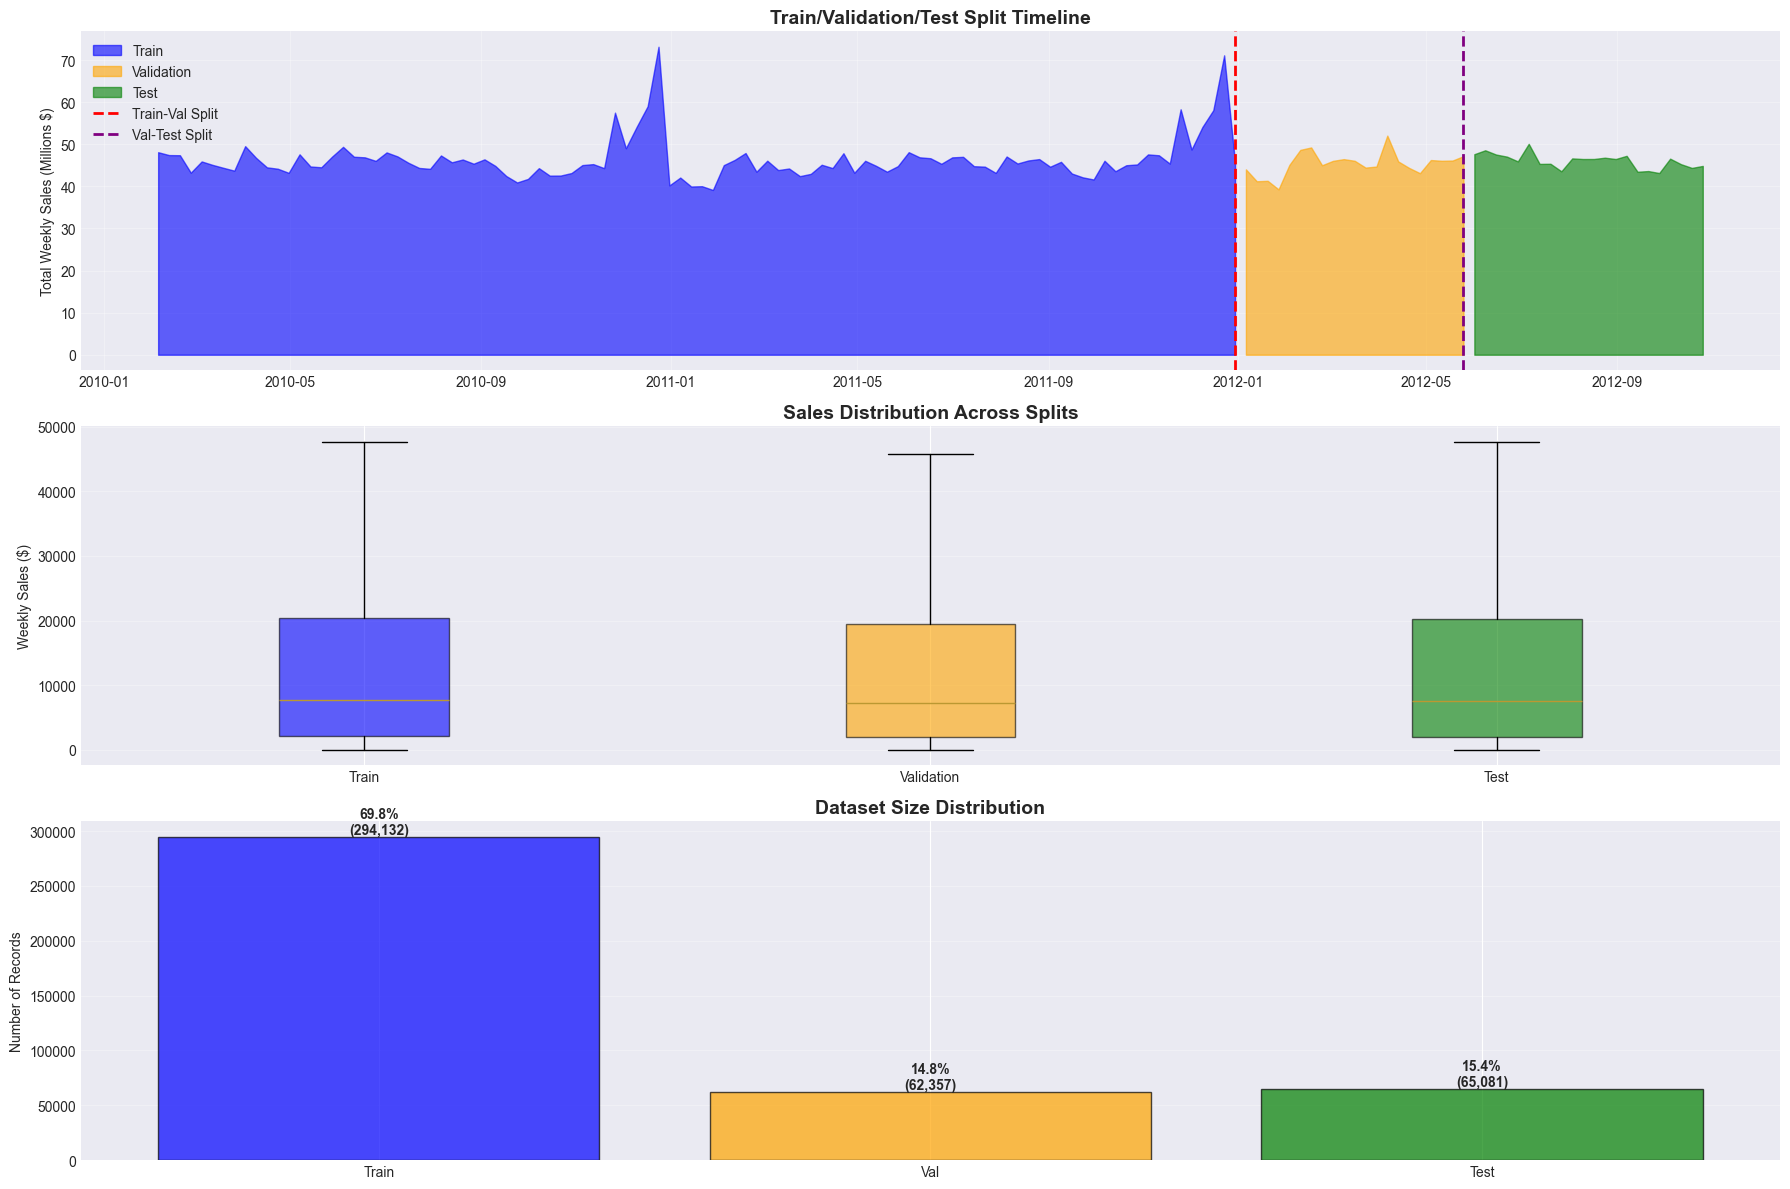


VALIDATION

1. Training Duration: 1.9 years
    PASS

2. No Overlap:  PASS

3. Train Proportion: 69.8%  PASS

 CHECKPOINT 1.5 PASSED!
 PHASE 1 COMPLETE! Ready for Phase 2.


In [61]:
#  walmart_checkpoint
print("=" * 80)
print("CHECKPOINT 1.5: SPLIT VISUALIZATION")
print("=" * 80)

train_df = pd.read_csv('../data/walmart_train.csv', parse_dates=['Date'])
val_df = pd.read_csv('../data/walmart_val.csv', parse_dates=['Date'])
test_df = pd.read_csv('../data/walmart_test.csv', parse_dates=['Date'])

fig, axes = plt.subplots(3, 1, figsize=(18, 12))

# Plot 1: Timeline with splits
ax1 = axes[0]

train_weekly = train_df.groupby('Date')['Weekly_Sales'].sum()
val_weekly = val_df.groupby('Date')['Weekly_Sales'].sum()
test_weekly = test_df.groupby('Date')['Weekly_Sales'].sum()

ax1.fill_between(train_weekly.index, train_weekly.values/1e6, alpha=0.6, color='blue', label='Train')
ax1.fill_between(val_weekly.index, val_weekly.values/1e6, alpha=0.6, color='orange', label='Validation')
ax1.fill_between(test_weekly.index, test_weekly.values/1e6, alpha=0.6, color='green', label='Test')

ax1.axvline(train_df['Date'].max(), color='red', linestyle='--', linewidth=2, label='Train-Val Split')
ax1.axvline(val_df['Date'].max(), color='purple', linestyle='--', linewidth=2, label='Val-Test Split')

ax1.set_title('Train/Validation/Test Split Timeline', fontsize=14, fontweight='bold')
ax1.set_ylabel('Total Weekly Sales (Millions $)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: Distribution comparison
ax2 = axes[1]

bp = ax2.boxplot(
    [train_df['Weekly_Sales'], val_df['Weekly_Sales'], test_df['Weekly_Sales']],
    labels=['Train', 'Validation', 'Test'],
    patch_artist=True,
    showfliers=False
)

colors = ['blue', 'orange', 'green']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax2.set_title('Sales Distribution Across Splits', fontsize=14, fontweight='bold')
ax2.set_ylabel('Weekly Sales ($)')
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Size comparison
ax3 = axes[2]

sizes = [len(train_df), len(val_df), len(test_df)]
percentages = [s/sum(sizes)*100 for s in sizes]

bars = ax3.bar(['Train', 'Val', 'Test'], sizes, color=colors, alpha=0.7, edgecolor='black')

for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{pct:.1f}%\n({int(height):,})',
             ha='center', va='bottom', fontweight='bold')

ax3.set_title('Dataset Size Distribution', fontsize=14, fontweight='bold')
ax3.set_ylabel('Number of Records')
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('walmart_checkpoint_1_5.png', dpi=300, bbox_inches='tight')
print("\n Checkpoint 1.5 saved")
plt.show()

# Validation
print("\n" + "="*80)
print("VALIDATION")
print("="*80)

train_weeks = len(train_df['Date'].unique())
train_years = train_weeks / 52

print(f"\n1. Training Duration: {train_years:.1f} years")
check1 = train_years >= 1.5
print(f"   {' PASS' if check1 else '✗ FAIL'}")

check2 = train_df['Date'].max() < val_df['Date'].min()
print(f"\n2. No Overlap: {' PASS' if check2 else ' FAIL'}")

train_pct = len(train_df) / len(pd.concat([train_df, val_df, test_df])) * 100
check3 = 65 <= train_pct <= 75
print(f"\n3. Train Proportion: {train_pct:.1f}% {' PASS' if check3 else ' WARNING'}")

if all([check1, check2, check3]):
    print("\n CHECKPOINT 1.5 PASSED!")
    print(" PHASE 1 COMPLETE! Ready for Phase 2.")
else:
    print("\n Some checks failed - review data")

### ***Satistical Models Phase***

In [62]:
!python '/kaggle/input/forecastingmodels/tensorflow2/default/1/statistical_models.py'

python: can't open file '/kaggle/input/forecastingmodels/tensorflow2/default/1/statistical_models.py': [Errno 2] No such file or directory


In [63]:
!python '/kaggle/input/forecastingmodels/tensorflow2/default/1/DeepLearning_Models.py'

python: can't open file '/kaggle/input/forecastingmodels/tensorflow2/default/1/DeepLearning_Models.py': [Errno 2] No such file or directory


In [64]:
!python '/kaggle/input/xgboost-ensemble/tensorflow2/default/1/XGBOOST.py'

python: can't open file '/kaggle/input/xgboost-ensemble/tensorflow2/default/1/XGBOOST.py': [Errno 2] No such file or directory
